## Setup and Data Loading

In [1]:
import sys
from pathlib import Path

notebook_dir = Path().resolve()
project_root = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import pearsonr
warnings.filterwarnings("ignore")

In [3]:
from src.config import (
    KEEP_COLS, SUBJECTS, GENDER_MAP, IMMIG_MAP, LOC_MAP, SCHLTYPE_MAP,
    PERCENTILES_COARSE, PERCENTILES_FINE, PALETTE,
    COUNTRY_COLORS, YEAR_COLORS, MIN_GROUP_N,
)

from src.data_loader import load_sample_csv
from src.pisa_stats import (
    weighted_mean_pv,
    weighted_percentiles_pv,
    compute_group_percentiles,
    compute_escs_quartile_percentiles,
    get_oecd_percentiles,
)

print("Imports done.")

Imports done.


In [4]:
# Global plot style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#eeeeee",
    "grid.linewidth":   0.7,
    "font.family":      "sans-serif",
    "font.size":        11,
})

COUNTRIES   = ["CAN", "USA"]
PERCS       = PERCENTILES_COARSE   
PERCS_FINE  = PERCENTILES_FINE     
COLORS      = COUNTRY_COLORS       

CNT_LABELS  = {"CAN": "Canada", "USA": "United States"}

In [5]:
# Load data 
DATA_PATH = project_root / "data" / "raw" / "sampledat.csv"

df = load_sample_csv(str(DATA_PATH))
df = df[df["CNT"].isin(COUNTRIES)].copy()

print(f"Loaded: {df.shape[0]:,} students x {df.shape[1]} columns")
print(df["CNT"].value_counts().to_string())

Loaded: 27,625 students x 134 columns
CNT
CAN    23073
USA     4552


## Data Quality - Missing Data Audit

In [6]:
AUDIT_VARS = {
    "Gender (ST004D01T)":      "ST004D01T",
    "School funding (SCHLTYPE)": "SCHLTYPE",
    "SES index (ESCS)":        "ESCS",
    "School location":         "SC001Q01TA",
    "Home possessions":        "HOMEPOS",
    "Parental educ. (PAREDINT)":"PAREDINT",
    "Grade repetition (REPEAT)":"REPEAT",
    "Immigration (IMMIG)":     "IMMIG",
    "Late arrivals":           "ST062Q03TA",
    "School belonging":        "BELONG",
    "Parental occ. (HISEI)":   "HISEI",
    "Math motivation":         "MATHMOT",
}

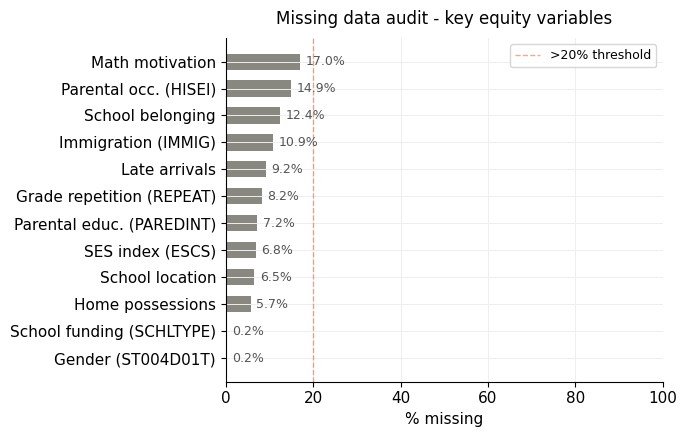

In [9]:
audit_rows = [
    {"Variable": label, "Missing (%)": round(df[col].isna().mean() * 100, 1)}
    for label, col in AUDIT_VARS.items()
    if col in df.columns
]
audit_df = pd.DataFrame(audit_rows).sort_values("Missing (%)")

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#D85A30" if v > 20 else "#888780" for v in audit_df["Missing (%)"]]
bars = ax.barh(audit_df["Variable"], audit_df["Missing (%)"],
               color=colors, height=0.6)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9, color="#555555")
ax.set_xlim(0, 100)
ax.set_xlabel("% missing")
ax.set_title("Missing data audit - key equity variables",
             fontsize=12, fontweight="500", pad=10)
ax.axvline(20, color="#D85A30", lw=1, ls="--", alpha=0.5, label=">20% threshold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## How do the two countries compare overall?

## 1. Score distributions across all three subjects

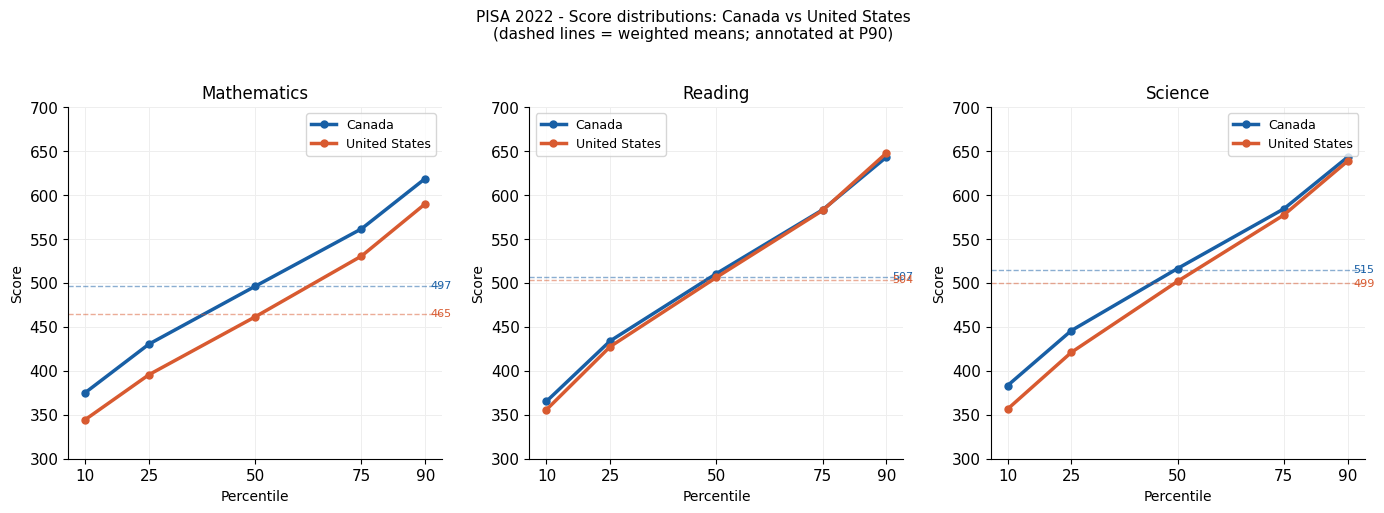

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for ax, (subj, name) in zip(axes, SUBJECTS.items()):
    for cnt in COUNTRIES:
        subset     = df[df["CNT"] == cnt]
        pv_percs   = weighted_percentiles_pv(subset, subj, PERCS)
        mean_score = weighted_mean_pv(subset, subj)

        ax.plot(PERCS, pv_percs,
                color=COLORS[cnt], lw=2.5, marker="o", ms=5,
                label=CNT_LABELS[cnt])
        ax.axhline(mean_score, color=COLORS[cnt], lw=1, ls="--", alpha=0.5)

        # annotate mean on the right edge
        ax.annotate(f"{mean_score:.0f}",
                    xy=(PERCS[-1], mean_score),
                    xytext=(4, 0), textcoords="offset points",
                    color=COLORS[cnt], fontsize=8, va="center")

    ax.set_title(name, fontsize=12, fontweight="500")
    ax.set_xlabel("Percentile", fontsize=10)
    ax.set_ylabel("Score", fontsize=10)
    ax.set_xticks(PERCS)
    ax.set_ylim(300, 700)
    ax.legend(fontsize=9)

fig.suptitle(
    "PISA 2022 - Score distributions: Canada vs United States\n"
    "(dashed lines = weighted means; annotated at P90)",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

## 2. P90-P10 spread by subject

In [11]:
# Build summary: mean, P10, P50, P90, spread 
rows = []
for cnt in COUNTRIES:
    subset = df[df["CNT"] == cnt]
    for subj, name in SUBJECTS.items():
        mean   = weighted_mean_pv(subset, subj)
        percs  = weighted_percentiles_pv(subset, subj, [10, 50, 90])
        rows.append({
            "Country": CNT_LABELS[cnt],
            "Subject": name,
            "Mean":    round(mean, 1),
            "P10":     round(percs[0], 1),
            "Median":  round(percs[1], 1),
            "P90":     round(percs[2], 1),
            "Spread (P90−P10)": round(percs[2] - percs[0], 1),
        })
summary = pd.DataFrame(rows)

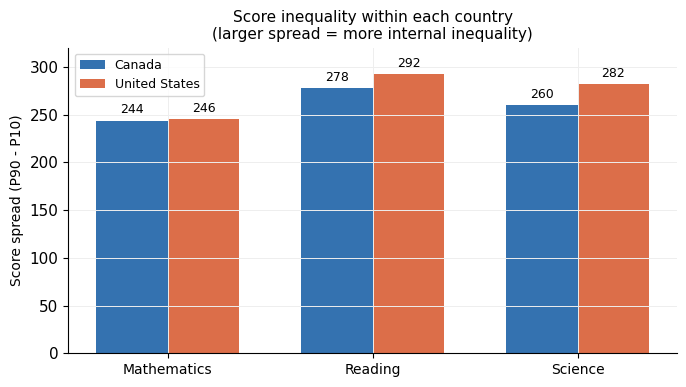


Summary table:
      Country     Subject  Mean   P10  Median   P90  Spread (P90−P10)
       Canada Mathematics 496.9 375.2   496.3 618.9             243.7
       Canada     Reading 507.1 365.3   510.7 643.2             278.0
       Canada     Science 515.0 383.3   516.5 643.2             259.9
United States Mathematics 464.9 344.5   461.5 590.1             245.6
United States     Reading 503.9 355.8   506.4 647.8             292.1
United States     Science 499.4 356.5   501.9 638.7             282.1


In [12]:
spread_pivot = summary.pivot(index="Subject", columns="Country",
                              values="Spread (P90−P10)")

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(spread_pivot))
w = 0.35
for i, cnt in enumerate(COUNTRIES):
    label = CNT_LABELS[cnt]
    vals  = spread_pivot[label].values
    bars  = ax.bar(x + i * w, vals, w,
                   label=label, color=COLORS[cnt], alpha=0.88)
    ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=9)

ax.set_xticks(x + w / 2)
ax.set_xticklabels(spread_pivot.index, fontsize=10)
ax.set_ylabel("Score spread (P90 - P10)", fontsize=10)
ax.set_ylim(0, 320)
ax.set_title("Score inequality within each country\n"
             "(larger spread = more internal inequality)",
             fontsize=11, fontweight="500")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nSummary table:")
print(summary.to_string(index=False))

## 3. Percentile gap plot

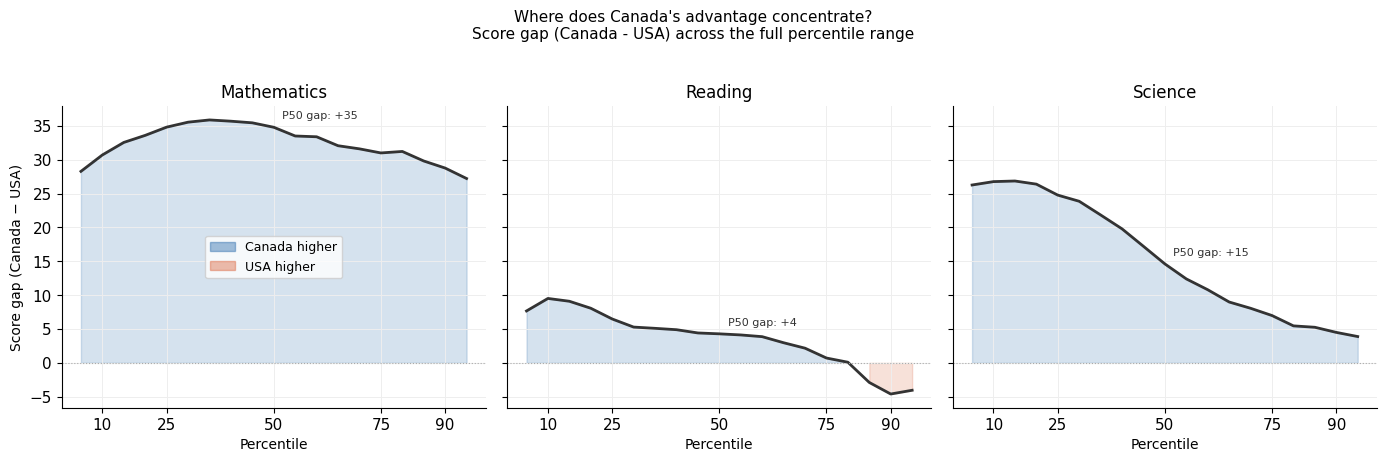

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for ax, (subj, name) in zip(axes, SUBJECTS.items()):
    can_percs = weighted_percentiles_pv(df[df["CNT"] == "CAN"], subj, PERCS_FINE)
    usa_percs = weighted_percentiles_pv(df[df["CNT"] == "USA"], subj, PERCS_FINE)
    gap       = can_percs - usa_percs

    # shade positive (CAN advantage) vs negative (USA advantage)
    ax.fill_between(PERCS_FINE, gap, 0,
                    where=(gap >= 0), alpha=0.18, color=COLORS["CAN"])
    ax.fill_between(PERCS_FINE, gap, 0,
                    where=(gap < 0),  alpha=0.18, color=COLORS["USA"])
    ax.plot(PERCS_FINE, gap, color="#333333", lw=2)
    ax.axhline(0, color="#aaaaaa", lw=0.8, ls=":")

    ax.set_title(name, fontsize=12, fontweight="500")
    ax.set_xlabel("Percentile", fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel("Score gap (Canada − USA)", fontsize=10)
    ax.set_xticks([10, 25, 50, 75, 90])

    # Annotate at median
    mid_idx = PERCS_FINE.index(50)
    ax.annotate(f"P50 gap: {gap[mid_idx]:+.0f}",
                xy=(50, gap[mid_idx]),
                xytext=(6, 6), textcoords="offset points",
                fontsize=8, color="#333333")

can_patch = mpatches.Patch(color=COLORS["CAN"], alpha=0.4, label="Canada higher")
usa_patch = mpatches.Patch(color=COLORS["USA"], alpha=0.4, label="USA higher")
axes[0].legend(handles=[can_patch, usa_patch], fontsize=9)

fig.suptitle(
    "Where does Canada's advantage concentrate?\n"
    "Score gap (Canada - USA) across the full percentile range",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

## Socioeconomic status, gender and immigration background

## 1. Socioeconomic status (ESCS)

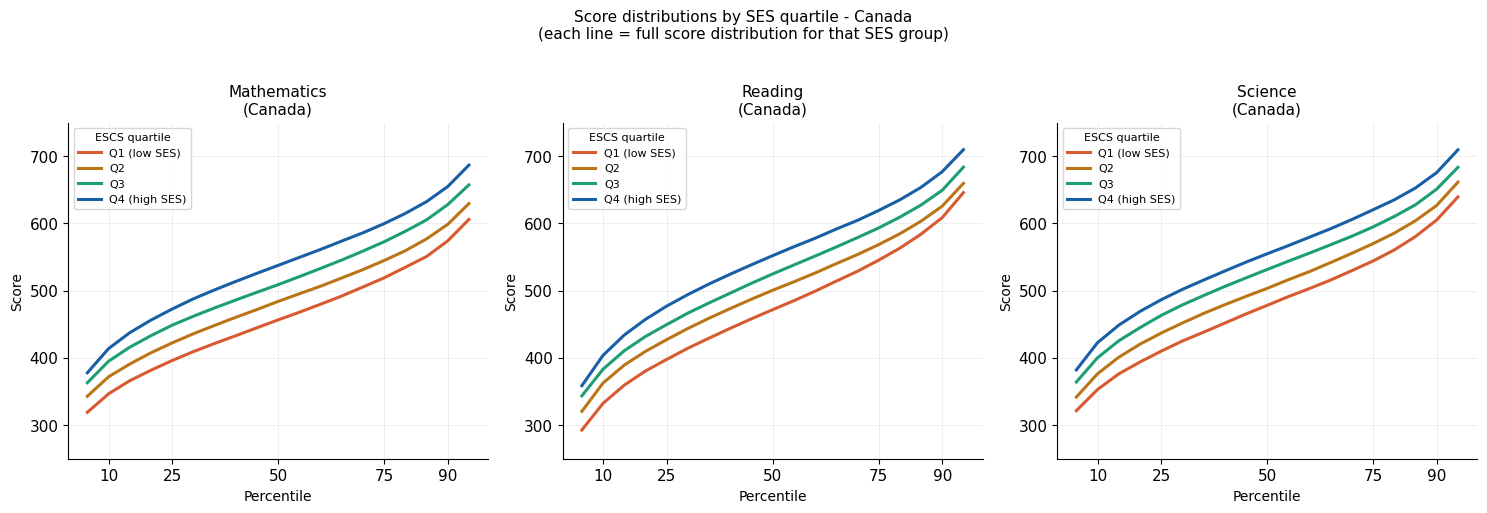

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

Q_LABELS  = ["Q1 (low SES)", "Q2", "Q3", "Q4 (high SES)"]
Q_PALETTE = PALETTE  

for ax, (subj, name) in zip(axes, SUBJECTS.items()):
    # use Canada as the showcase country for the distribution view
    curves = compute_escs_quartile_percentiles(
        df, subj, PERCS_FINE, cnt="CAN"
    )
    for q_label, color in zip(Q_LABELS, Q_PALETTE):
        curve = curves.get(q_label)
        if curve is None or np.isnan(curve).all():
            continue
        ax.plot(PERCS_FINE, curve, color=color, lw=2.2,
                label=q_label)

    ax.set_title(f"{name}\n(Canada)", fontsize=11, fontweight="500")
    ax.set_xlabel("Percentile", fontsize=10)
    ax.set_ylabel("Score", fontsize=10)
    ax.set_xticks([10, 25, 50, 75, 90])
    ax.set_ylim(250, 750)
    ax.legend(title="ESCS quartile", fontsize=8, title_fontsize=8)

fig.suptitle(
    "Score distributions by SES quartile - Canada\n"
    "(each line = full score distribution for that SES group)",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

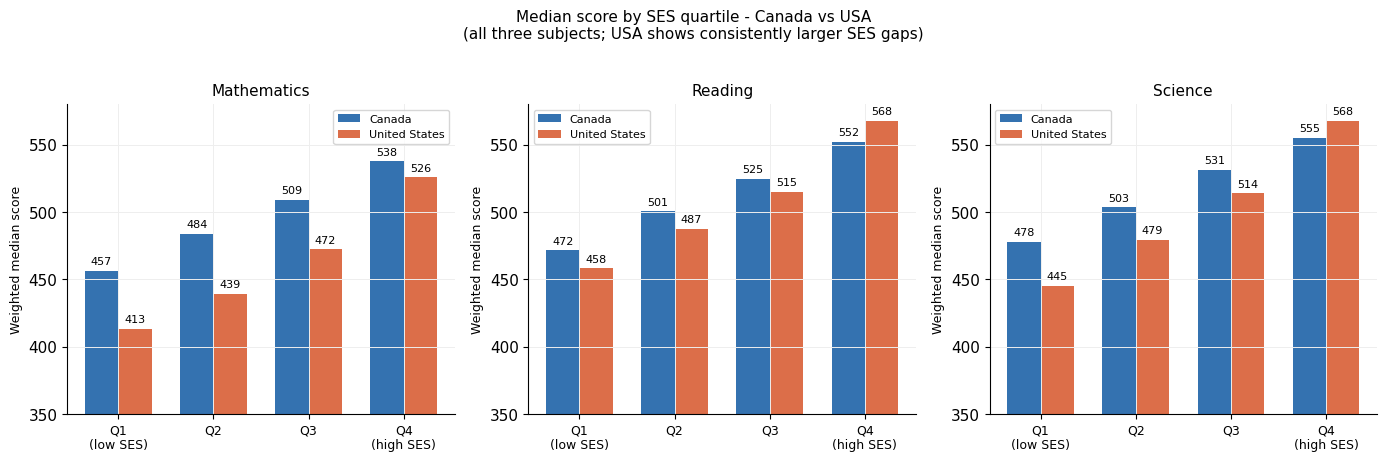

SES gap (Q4 median - Q1 median):
  Canada           Mathematics  : +81.1 pts
  Canada           Reading      : +80.4 pts
  Canada           Science      : +76.7 pts
  United States    Mathematics  : +112.3 pts
  United States    Reading      : +109.4 pts
  United States    Science      : +122.6 pts


In [15]:
# SES gap: Q4 mean minus Q1 mean, both countries, all subjects 
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (subj, name) in zip(axes, SUBJECTS.items()):
    x     = np.arange(4)
    width = 0.35

    for i, cnt in enumerate(COUNTRIES):
        curves = compute_escs_quartile_percentiles(df, subj, [50], cnt=cnt)
        means  = []
        for q in Q_LABELS:
            curve = curves.get(q, np.array([np.nan]))
            means.append(curve[0] if not np.isnan(curve).all() else np.nan)

        bars = ax.bar(x + i * width, means, width,
                      label=CNT_LABELS[cnt], color=COLORS[cnt], alpha=0.88)
        ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=8)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(["Q1\n(low SES)", "Q2", "Q3", "Q4\n(high SES)"],
                       fontsize=9)
    ax.set_ylim(350, 580)
    ax.set_ylabel("Weighted median score", fontsize=9)
    ax.set_title(name, fontsize=11, fontweight="500")
    ax.legend(fontsize=8)

fig.suptitle(
    "Median score by SES quartile - Canada vs USA\n"
    "(all three subjects; USA shows consistently larger SES gaps)",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

# Print gap sizes 
print("SES gap (Q4 median - Q1 median):")
for cnt in COUNTRIES:
    for subj, name in SUBJECTS.items():
        curves = compute_escs_quartile_percentiles(df, subj, [50], cnt=cnt)
        q1 = curves.get("Q1 (low SES)", np.array([np.nan]))[0]
        q4 = curves.get("Q4 (high SES)", np.array([np.nan]))[0]
        print(f"  {CNT_LABELS[cnt]:16s} {name:13s}: {q4 - q1:+.1f} pts")

## 2. ESCS gap across the distribution

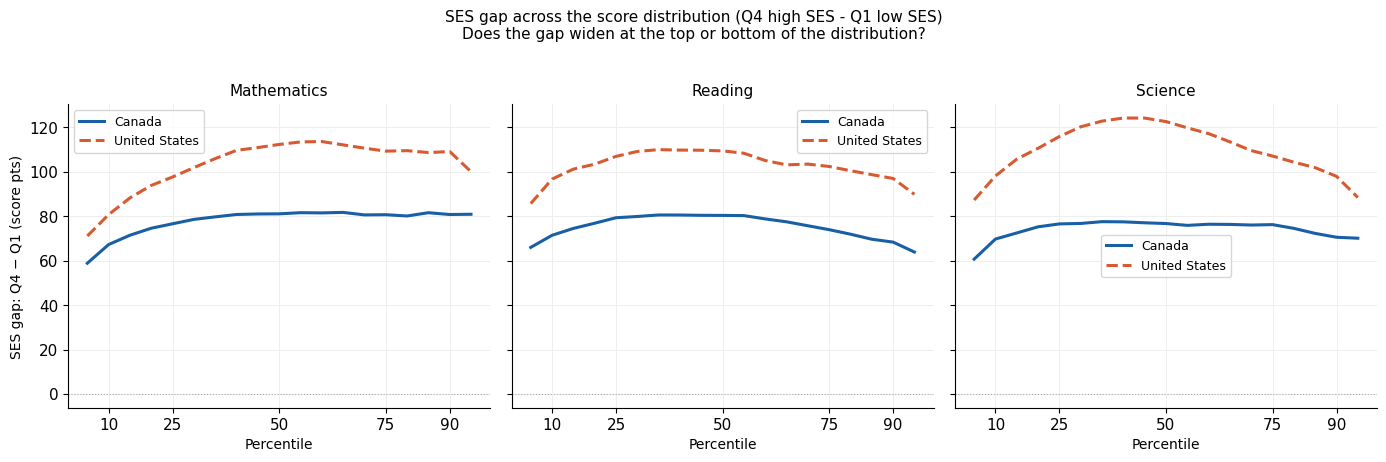

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for ax, (subj, name) in zip(axes, SUBJECTS.items()):
    for cnt in COUNTRIES:
        curves = compute_escs_quartile_percentiles(
            df, subj, PERCS_FINE, cnt=cnt
        )
        q1_curve = curves.get("Q1 (low SES)")
        q4_curve = curves.get("Q4 (high SES)")

        if q1_curve is None or q4_curve is None:
            continue
        if np.isnan(q1_curve).all() or np.isnan(q4_curve).all():
            continue

        gap = q4_curve - q1_curve
        ls  = "--" if cnt == "USA" else "-"
        ax.plot(PERCS_FINE, gap, color=COLORS[cnt], lw=2.2,
                ls=ls, label=CNT_LABELS[cnt])

    ax.axhline(0, color="#aaaaaa", lw=0.8, ls=":")
    ax.set_title(name, fontsize=11, fontweight="500")
    ax.set_xlabel("Percentile", fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel("SES gap: Q4 − Q1 (score pts)", fontsize=10)
    ax.set_xticks([10, 25, 50, 75, 90])
    ax.legend(fontsize=9)

fig.suptitle(
    "SES gap across the score distribution (Q4 high SES - Q1 low SES)\n"
    "Does the gap widen at the top or bottom of the distribution?",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

## 3. Gender gap across the distribution 

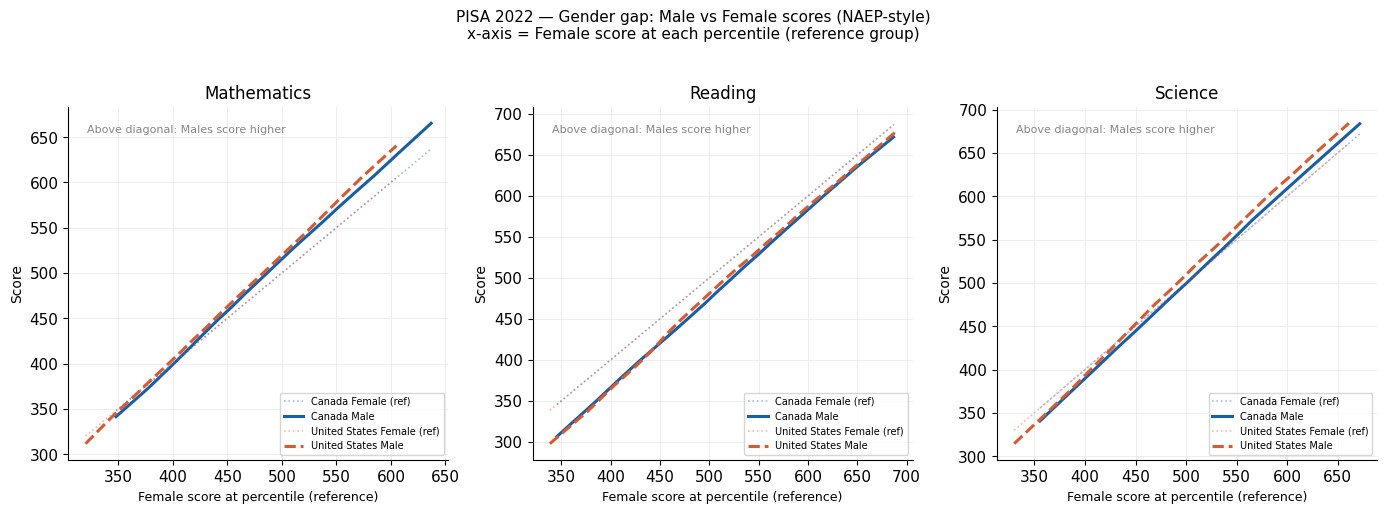

In [17]:
df_gen = df.dropna(subset=["ST004D01T"]).copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for ax, (subj, name) in zip(axes, SUBJECTS.items()):
    for cnt in COUNTRIES:
        subset_cnt  = df_gen[df_gen["CNT"] == cnt]
        female_data = subset_cnt[subset_cnt["ST004D01T"] == 1.0]
        male_data   = subset_cnt[subset_cnt["ST004D01T"] == 2.0]

        female_percs = weighted_percentiles_pv(female_data, subj, PERCS_FINE)
        male_percs   = weighted_percentiles_pv(male_data,   subj, PERCS_FINE)

        ls = "--" if cnt == "USA" else "-"
        # female reference diagonal
        ax.plot(female_percs, female_percs,
                color=COLORS[cnt], lw=1.2, ls=":", alpha=0.4,
                label=f"{CNT_LABELS[cnt]} Female (ref)")
        # male line plotted against female reference scale
        ax.plot(female_percs, male_percs,
                color=COLORS[cnt], lw=2.2, ls=ls,
                label=f"{CNT_LABELS[cnt]} Male")

    ax.set_title(name, fontsize=12, fontweight="500")
    ax.set_xlabel("Female score at percentile (reference)", fontsize=9)
    ax.set_ylabel("Score", fontsize=10)
    ax.legend(fontsize=7)
    ax.text(0.05, 0.95, "Above diagonal: Males score higher",
            transform=ax.transAxes, fontsize=8,
            color="#888780", va="top")

fig.suptitle(
    "PISA 2022 — Gender gap: Male vs Female scores (NAEP-style)\n"
    "x-axis = Female score at each percentile (reference group)",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

In [18]:
# Gender gap magnitude: Male - Female at each coarse percentile 
print("Gender gap (Male - Female score, in points):")
print(f"{'Country':16s} {'Subject':13s} " +
      "  ".join([f"P{p}" for p in PERCS]))
print("-" * 75)
for cnt in COUNTRIES:
    subset_cnt = df_gen[df_gen["CNT"] == cnt]
    for subj, name in SUBJECTS.items():
        f_percs = weighted_percentiles_pv(
            subset_cnt[subset_cnt["ST004D01T"] == 1.0], subj, PERCS)
        m_percs = weighted_percentiles_pv(
            subset_cnt[subset_cnt["ST004D01T"] == 2.0], subj, PERCS)
        gaps = m_percs - f_percs
        print(f"{CNT_LABELS[cnt]:16s} {name:13s} " +
              "  ".join([f"{g:+6.1f}" for g in gaps]))

Gender gap (Male - Female score, in points):
Country          Subject       P10  P25  P50  P75  P90
---------------------------------------------------------------------------
Canada           Mathematics     -4.7    +4.5   +13.9   +20.5   +25.2
Canada           Reading        -35.8   -29.7   -23.5   -17.4   -14.2
Canada           Science        -11.4    -5.8    +0.9    +7.8   +10.5
United States    Mathematics     -2.8    +3.6   +13.6   +22.2   +32.3
United States    Reading        -39.4   -30.5   -17.6   -13.5   -11.9
United States    Science        -12.3    -3.0    +8.9   +17.6   +21.9


## 4. Immigration status

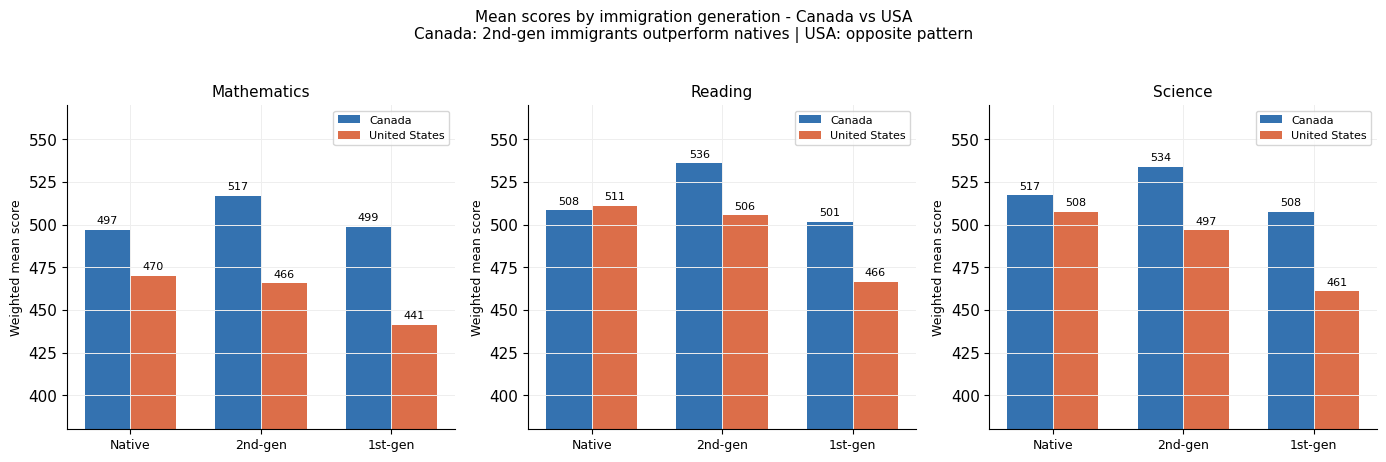

In [19]:
df_immig = df.dropna(subset=["IMMIG"]).copy()

# Bar chart: mean by immigration status, both countries
IMMIG_CODES  = {1.0: "Native", 2.0: "2nd-gen", 3.0: "1st-gen"}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (subj, name) in zip(axes, SUBJECTS.items()):
    x     = np.arange(len(IMMIG_CODES))
    width = 0.35
    for i, cnt in enumerate(COUNTRIES):
        means = []
        for code in IMMIG_CODES:
            subset = df_immig[
                (df_immig["IMMIG"] == code) & (df_immig["CNT"] == cnt)
            ]
            means.append(
                weighted_mean_pv(subset, subj)
                if len(subset) >= MIN_GROUP_N else np.nan
            )
        bars = ax.bar(x + i * width, means, width,
                      label=CNT_LABELS[cnt], color=COLORS[cnt], alpha=0.88)
        ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=8)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(list(IMMIG_CODES.values()), fontsize=9)
    ax.set_ylim(380, 570)
    ax.set_ylabel("Weighted mean score", fontsize=9)
    ax.set_title(name, fontsize=11, fontweight="500")
    ax.legend(fontsize=8)

fig.suptitle(
    "Mean scores by immigration generation - Canada vs USA\n"
    "Canada: 2nd-gen immigrants outperform natives | USA: opposite pattern",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

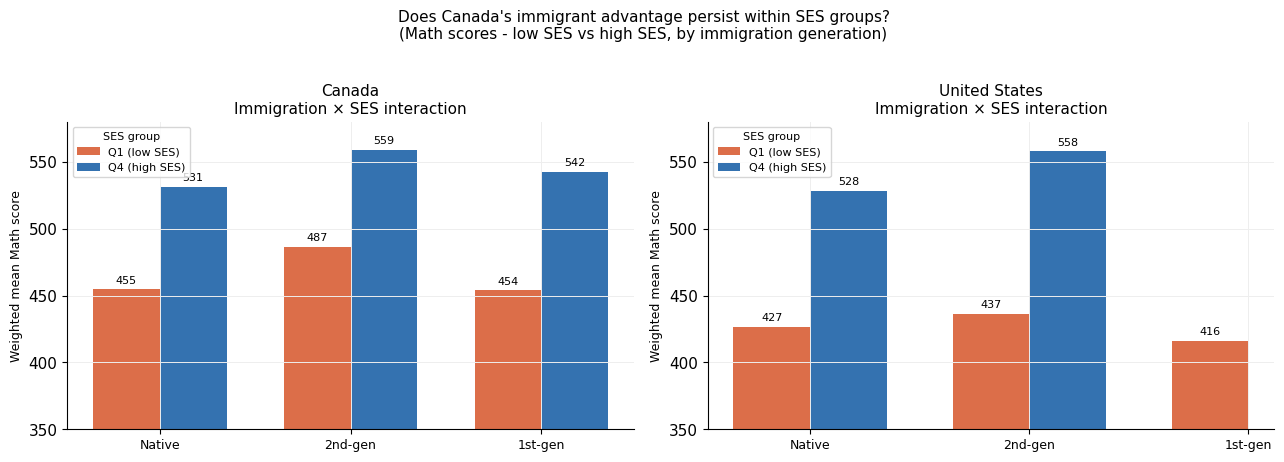

In [20]:
# Immigration × SES interaction 

df_both = df.dropna(subset=["IMMIG", "ESCS"]).copy()
df_both["SES_GROUP"] = pd.qcut(
    df_both["ESCS"], q=4,
    labels=["Q1 (low SES)", "Q2", "Q3", "Q4 (high SES)"]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, cnt in zip(axes, COUNTRIES):
    subset_cnt = df_both[df_both["CNT"] == cnt]
    x          = np.arange(len(IMMIG_CODES))
    width      = 0.35

    for i, (ses_label, ses_color) in enumerate(
        [("Q1 (low SES)", PALETTE[0]), ("Q4 (high SES)", PALETTE[3])]
    ):
        means = []
        for code in IMMIG_CODES:
            sub = subset_cnt[
                (subset_cnt["IMMIG"] == code) &
                (subset_cnt["SES_GROUP"] == ses_label)
            ]
            means.append(
                weighted_mean_pv(sub, "MATH")
                if len(sub) >= MIN_GROUP_N else np.nan
            )
        bars = ax.bar(x + i * width, means, width,
                      label=ses_label, color=ses_color, alpha=0.88)
        ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=8)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(list(IMMIG_CODES.values()), fontsize=9)
    ax.set_ylim(350, 580)
    ax.set_ylabel("Weighted mean Math score", fontsize=9)
    ax.set_title(f"{CNT_LABELS[cnt]}\nImmigration × SES interaction",
                 fontsize=11, fontweight="500")
    ax.legend(title="SES group", fontsize=8, title_fontsize=8)

fig.suptitle(
    "Does Canada's immigrant advantage persist within SES groups?\n"
    "(Math scores - low SES vs high SES, by immigration generation)",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

## 5. Grade repetition and school belonging

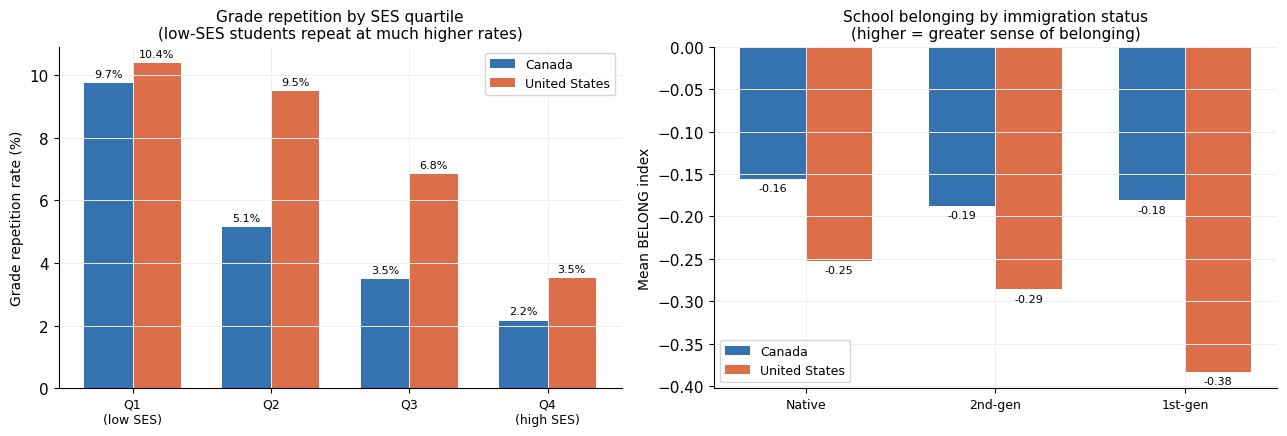

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: Grade repetition rate by SES quartile 
ax = axes[0]
df_rep = df.dropna(subset=["REPEAT", "ESCS"]).copy()
df_rep["ESCS_Q"] = pd.qcut(
    df_rep["ESCS"], q=4,
    labels=["Q1\n(low SES)", "Q2", "Q3", "Q4\n(high SES)"]
)

x     = np.arange(4)
width = 0.35
q_tick_labels = ["Q1\n(low SES)", "Q2", "Q3", "Q4\n(high SES)"]

for i, cnt in enumerate(COUNTRIES):
    rates = []
    for q in q_tick_labels:
        sub = df_rep[(df_rep["ESCS_Q"] == q) & (df_rep["CNT"] == cnt)]
        if len(sub) < MIN_GROUP_N:
            rates.append(np.nan)
        else:
            # REPEAT == 1 means repeated (value 1=yes, 2=no in PISA coding)
            rate = (sub["REPEAT"] == 1).mean() * 100
            rates.append(rate)
    bars = ax.bar(x + i * width, rates, width,
                  label=CNT_LABELS[cnt], color=COLORS[cnt], alpha=0.88)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(q_tick_labels, fontsize=9)
ax.set_ylabel("Grade repetition rate (%)", fontsize=10)
ax.set_title("Grade repetition by SES quartile\n"
             "(low-SES students repeat at much higher rates)",
             fontsize=11, fontweight="500")
ax.legend(fontsize=9)

# Right: School belonging by immigration status
ax = axes[1]
df_bel = df.dropna(subset=["BELONG", "IMMIG"]).copy()

x     = np.arange(len(IMMIG_CODES))
for i, cnt in enumerate(COUNTRIES):
    means = []
    for code in IMMIG_CODES:
        sub = df_bel[(df_bel["IMMIG"] == code) & (df_bel["CNT"] == cnt)]
        means.append(sub["BELONG"].mean() if len(sub) >= MIN_GROUP_N else np.nan)
    bars = ax.bar(x + i * width, means, width,
                  label=CNT_LABELS[cnt], color=COLORS[cnt], alpha=0.88)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(list(IMMIG_CODES.values()), fontsize=9)
ax.set_ylabel("Mean BELONG index", fontsize=10)
ax.set_title("School belonging by immigration status\n"
             "(higher = greater sense of belonging)",
             fontsize=11, fontweight="500")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. Equity variable correlations

In [22]:
CORR_COLS = {
    "Math (PV1)":      "PV1MATH",
    "Reading (PV1)":   "PV1READ",
    "Science (PV1)":   "PV1SCIE",
    "SES (ESCS)":      "ESCS",
    "Home poss.":      "HOMEPOS",
    "Parental educ.":  "PAREDINT",
    "Belonging":       "BELONG",
    "Math motivation": "MATHMOT",
    "Age":             "AGE",
    "Grade":           "GRADE",
}

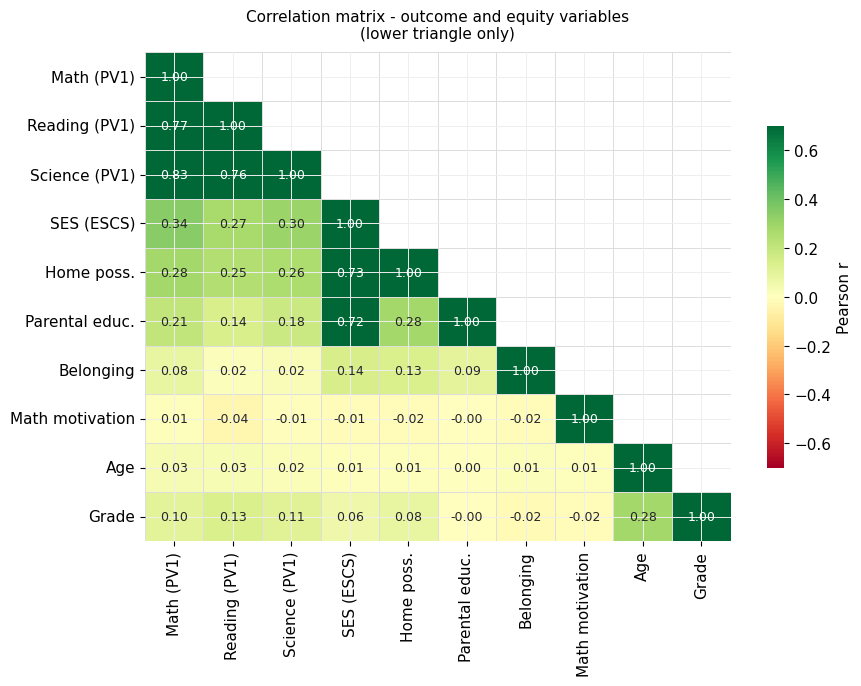

In [23]:
available = {k: v for k, v in CORR_COLS.items() if v in df.columns}
corr_df   = df[[v for v in available.values()]].copy()
corr_df.columns = list(available.keys())
corr_mat  = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(
    corr_mat, ax=ax,
    mask=mask,
    cmap="RdYlGn", center=0, vmin=-0.7, vmax=0.7,
    annot=True, fmt=".2f", annot_kws={"size": 9},
    linewidths=0.5, linecolor="#dddddd",
    cbar_kws={"shrink": 0.7, "label": "Pearson r"}
)
ax.set_title(
    "Correlation matrix - outcome and equity variables\n"
    "(lower triangle only)",
    fontsize=11, fontweight="500", pad=10
)
plt.tight_layout()
plt.show()